In [1]:
import os

import numpy as np
import pandas as pd
import xarray as xr
import glob
from scipy.integrate import trapz  # import a single function for integration using trapezoidal rule

import multiprocessing
import matplotlib.pyplot as plt
import matplotlib as mpl

rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

plt.rcParams.update({'font.size': 18, 'axes.labelsize': 22})

import PyMieScatt as ps

from mie_perso import PSD, Processor,SizeParam

opj = os.path.join

### Load the multi-processor mie object

In [2]:
pmie = Processor()


### Set input parameters
- the size parameter $x=2\pi r / \lambda$ with $r$ the radius of your spherical homogeneous particle
- the complex refractive index $m=m_r+im_i$

You can also set up the scattering angles you want with `theta` in radians

In [3]:
# set refractive index
m = 1.17 - 0.001j

# set size parameter
x=[50]

# set scattering angles
theta = np.linspace(0, np.pi, 3600)

# proceed with computation
scat_mat = pmie.ScatMat_mp(m, x, theta)
scat_mat

<xarray.Dataset>
Dimensions:  (x: 1, theta: 3600)
Coordinates:
  * x        (x) int64 50
  * theta    (theta) float64 0.0 0.0008729 0.001746 ... 3.14 3.141 3.142
    nr       float64 1.17
    ni       float64 -0.001
Data variables:
    S11      (x, theta) float64 2.388e+06 2.387e+06 ... 7.33e+03 7.337e+03
    S12      (x, theta) float64 0.0 -1.743 -6.966 -15.66 ... 2.651 0.6638 0.0
    S33      (x, theta) float64 2.388e+06 2.387e+06 ... -7.33e+03 -7.337e+03
    S34      (x, theta) float64 0.0 59.81 238.9 536.5 ... 30.2 13.47 3.375 0.0
Attributes:
    description:  non-null scattering matrix terms from Mie computations usin...

#### Visualization of the scattering matrix

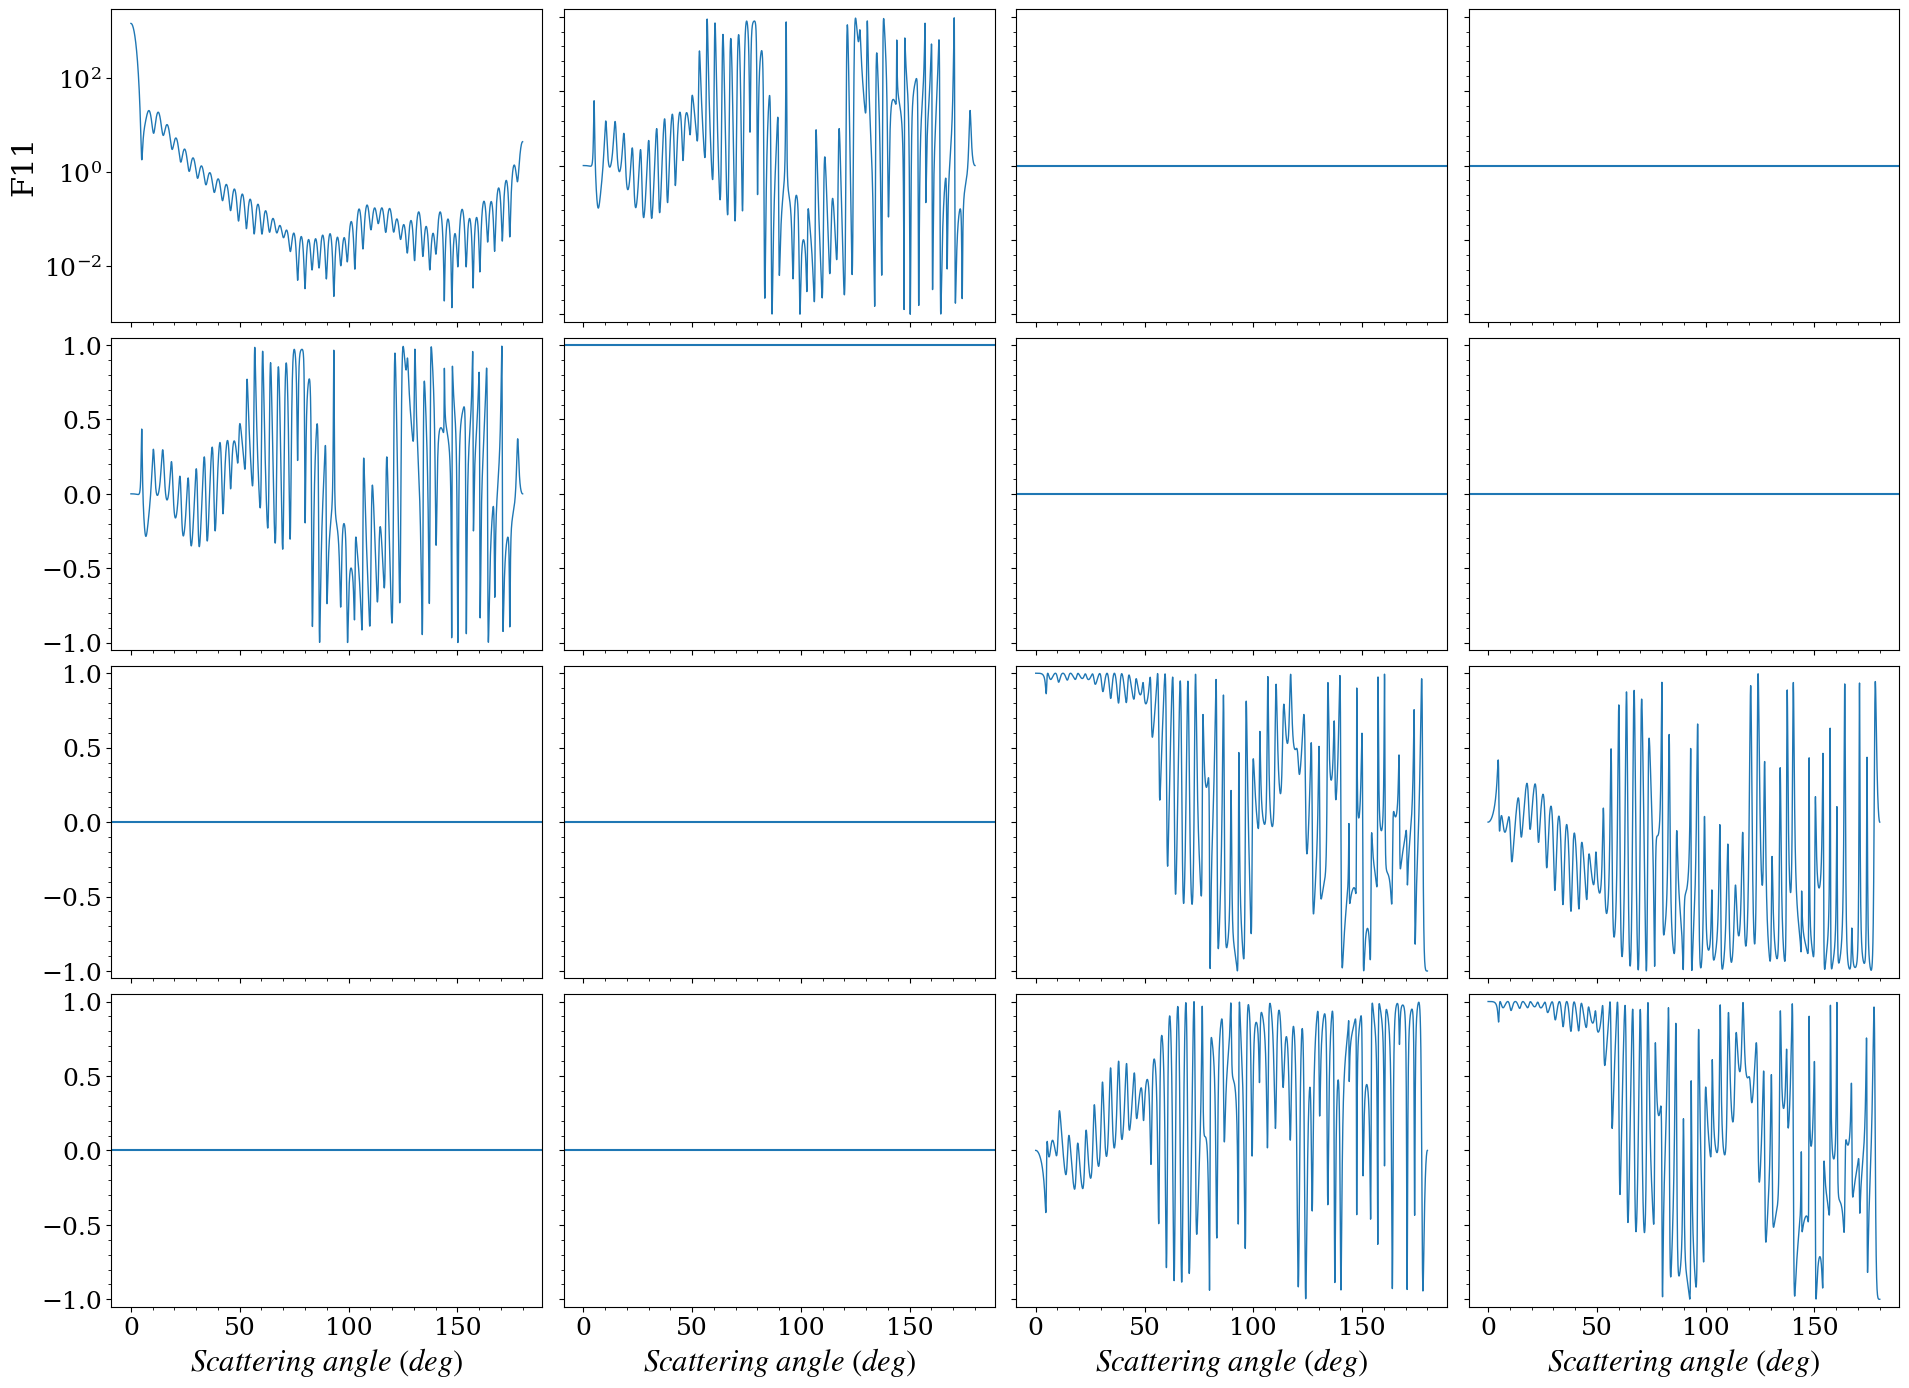

In [4]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 15), sharex=True)#, sharey='row')
fig.subplots_adjust(bottom=0.115, top=0.98, left=0.086, right=0.98,
                    hspace=0.05, wspace=0.05)
ang=np.degrees(theta)
S11 = scat_mat.S11.squeeze()
S12 = scat_mat.S12.squeeze()
S33 = scat_mat.S33.squeeze()
S34 = scat_mat.S34.squeeze()


norm = trapz(S11 * np.sin(theta), theta) / 2
axs[0, 0].plot(ang, S11 / norm, lw=1)
axs[0, 0].semilogy()
axs[0, 1].plot(ang, S12 / S11, lw=1)
axs[1, 0].plot(ang, S12 / S11, lw=1)
axs[2, 2].plot(ang, S33 / S11, lw=1)
axs[3, 3].plot(ang, S33 / S11, lw=1)
axs[2, 3].plot(ang, S34 / S11, lw=1)
axs[3, 2].plot(ang, -S34 / S11, lw=1)
axs[1, 1].axhline(1)
axs[0, 2].axhline(0)
axs[0, 3].axhline(0)
axs[1, 2].axhline(0)
axs[1, 3].axhline(0)
axs[2, 0].axhline(0)
axs[3, 0].axhline(0)
axs[2, 1].axhline(0)
axs[3, 1].axhline(0)

axs[0, 0].set_ylabel('F11')

for i in range(4):
    axs[i,1].set_yticklabels([])
    axs[i,2].set_yticklabels([])
    axs[i,3].set_yticklabels([])
    axs[-1, i].set_xlabel(r'$Scattering\ angle\ (deg)$')
    for j in range(4):
        if (i==0) and (j==0):
            continue
        axs[i,j].set_ylim([-1.05, 1.05])

for ax in axs.ravel():
    ax.minorticks_on()

Plot the four independent terms (e.g., non-null)

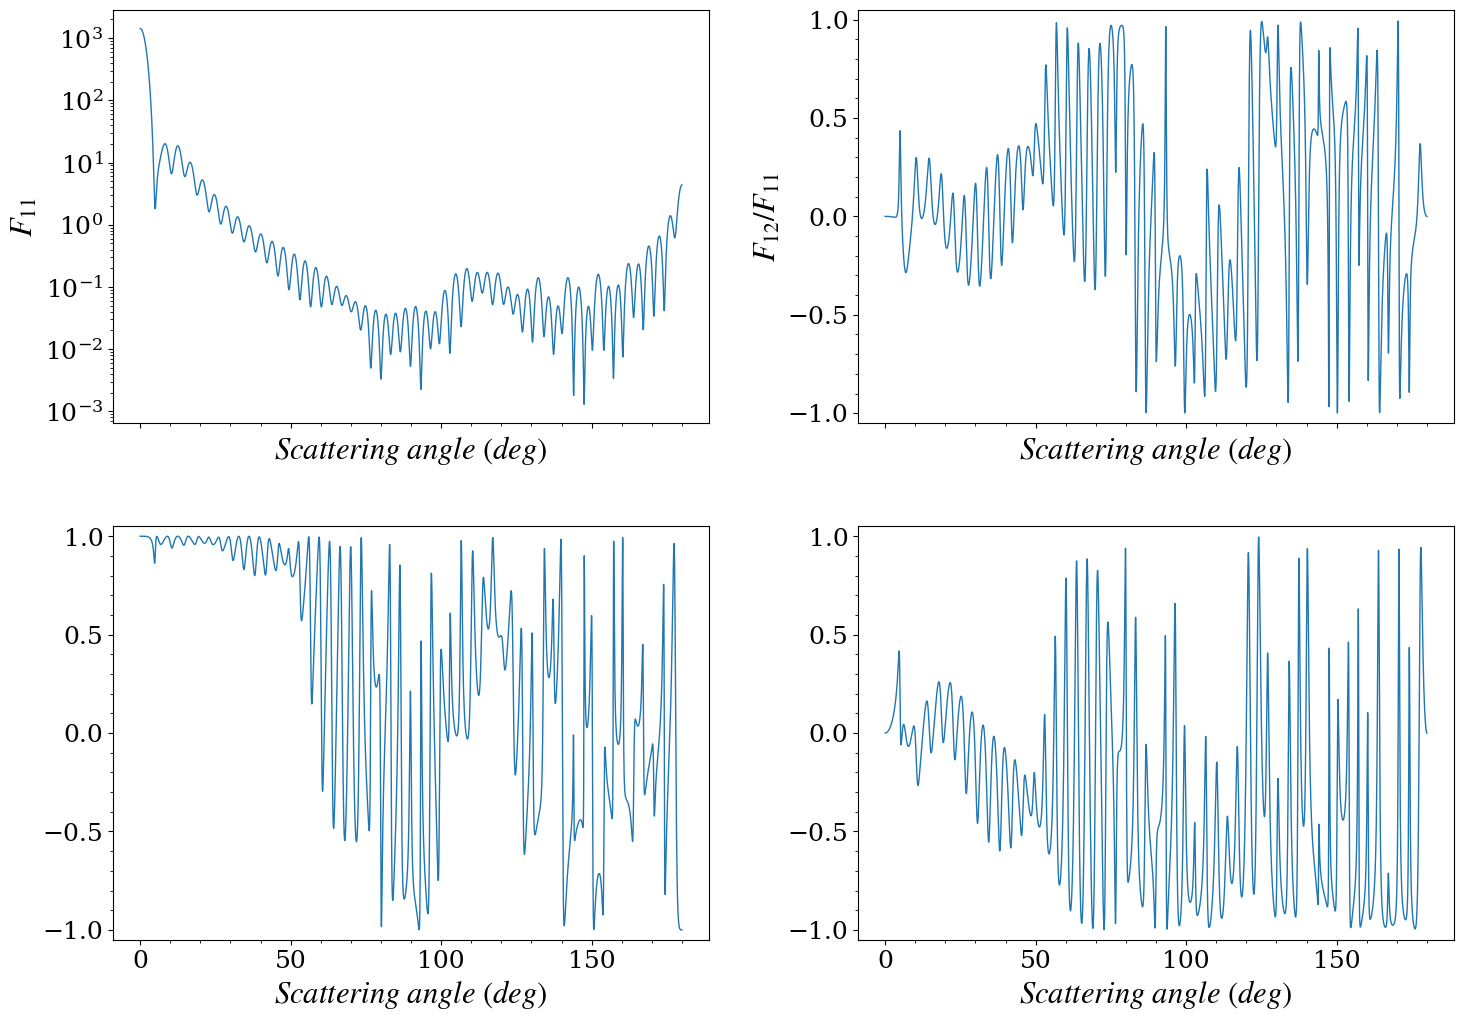

In [5]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True)#, sharey='row')
fig.subplots_adjust(bottom=0.05, top=0.98, left=0.086, right=0.98,
                    hspace=0.25, wspace=0.25)
ang=np.degrees(theta)
S11 = scat_mat.S11.squeeze()
S12 = scat_mat.S12.squeeze()
S33 = scat_mat.S33.squeeze()
S34 = scat_mat.S34.squeeze()


norm = trapz(S11 * np.sin(theta), theta) / 2
axs[0, 0].plot(ang, S11 / norm, lw=1)
axs[0, 0].semilogy()
axs[0, 1].plot(ang, S12 / S11, lw=1)
axs[1,0].plot(ang, S33 / S11, lw=1)
axs[1, 1].plot(ang, S34 / S11, lw=1)

axs[0, 0].set_ylabel(r'$F_{11}$')
axs[0, 1].set_ylabel(r'$F_{12}/F_{11}$')
for i in range(2):
   
    for j in range(2):
        if (i==0) and (j==0):
            continue
        axs[i,j].set_ylim([-1.05, 1.05])

for ax in axs.ravel():
    ax.minorticks_on()
    ax.set_xlabel(r'$Scattering\ angle\ (deg)$')

### Run it for a series of size parameters

In [6]:
# set refractive index
m = 1.17 - 0.001j

# set size parameter
x=np.linspace(1,50,10)

# set scattering angles
theta = np.linspace(0, np.pi, 3600)

# proceed with computation
scat_mat = pmie.ScatMat_mp(m, x, theta)
scat_mat

<xarray.Dataset>
Dimensions:  (x: 10, theta: 3600)
Coordinates:
  * x        (x) float64 1.0 6.444 11.89 17.33 22.78 ... 33.67 39.11 44.56 50.0
  * theta    (theta) float64 0.0 0.0008729 0.001746 ... 3.14 3.141 3.142
    nr       float64 1.17
    ni       float64 -0.001
Data variables:
    S11      (x, theta) float64 0.01356 0.01356 0.01356 ... 7.33e+03 7.337e+03
    S12      (x, theta) float64 0.0 -5.007e-09 -2.003e-08 ... 2.651 0.6638 0.0
    S33      (x, theta) float64 0.01356 0.01356 0.01356 ... -7.33e+03 -7.337e+03
    S34      (x, theta) float64 0.0 -5.247e-12 -2.099e-11 ... 13.47 3.375 0.0
Attributes:
    description:  non-null scattering matrix terms from Mie computations usin...

Plot scattering matrices for the different size parameters

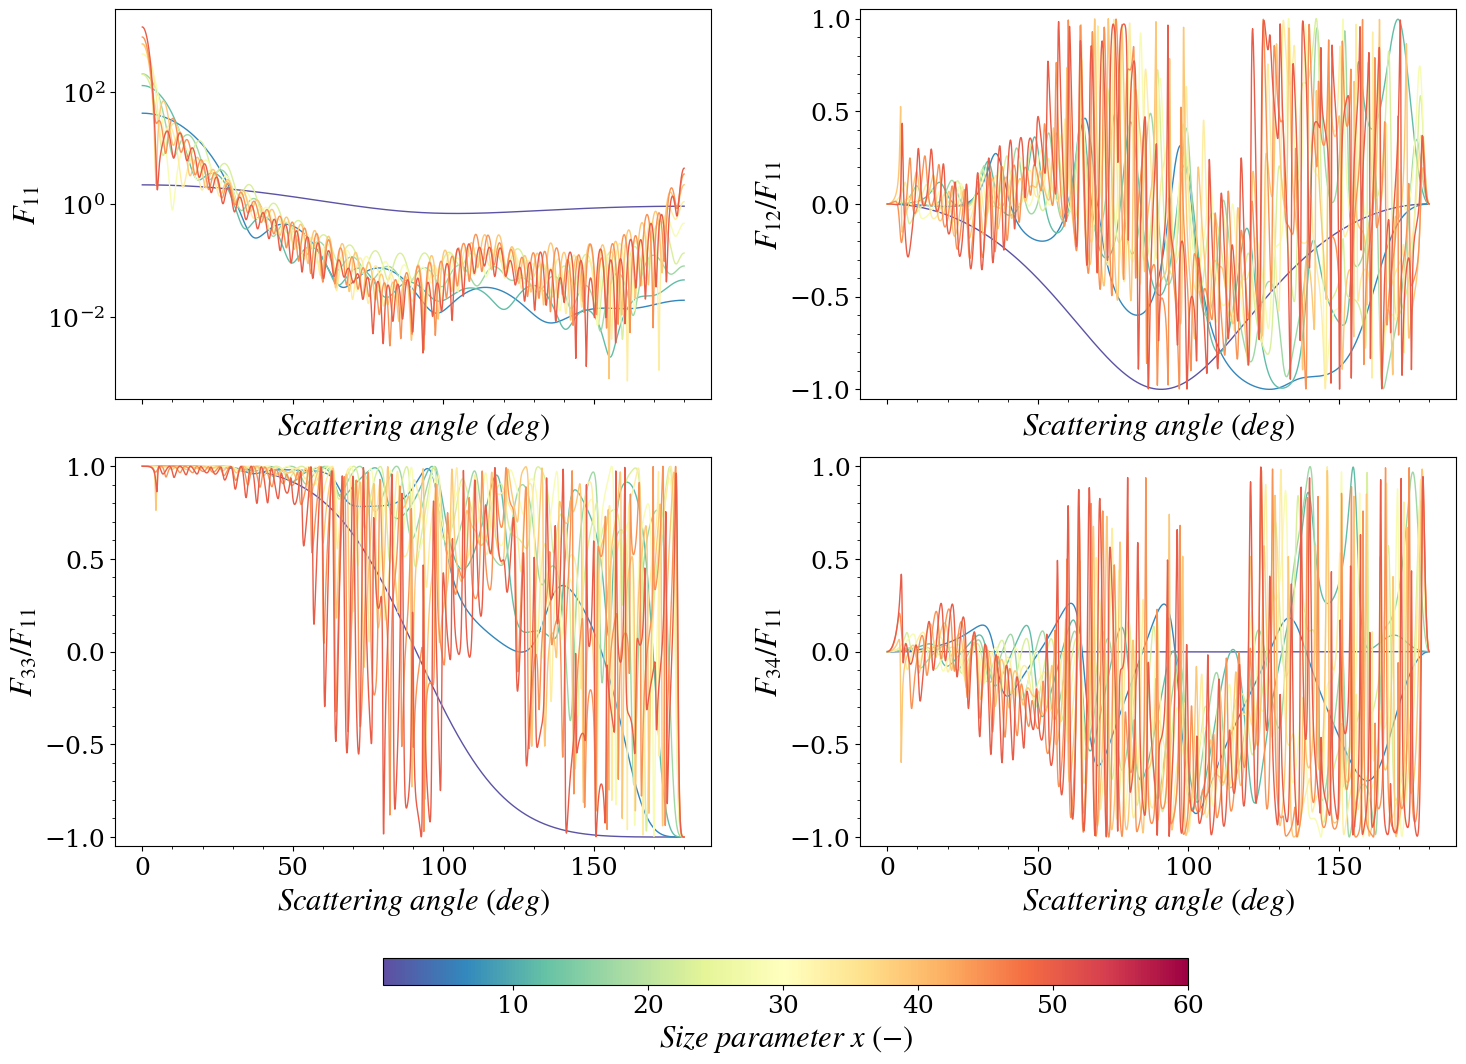

In [7]:

# Prepare color scale
cmap = plt.cm.Spectral_r #mpl.colors.LinearSegmentedColormap.from_list("",['navy', "blue", 'lightskyblue', 'gray', 'yellowgreen', 'forestgreen','gold','darkgoldenrod','darkred','black'])

norm = mpl.colors.Normalize(vmin=0.4, vmax=60)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True)#, sharey='row')
fig.subplots_adjust(bottom=0.05, top=0.98, left=0.086, right=0.98,
                    hspace=0.15, wspace=0.25)
ang=np.degrees(theta)

for x, scat_mat_ in scat_mat.groupby('x'):
    S11 = scat_mat_.S11.squeeze()
    S12 = scat_mat_.S12.squeeze()
    S33 = scat_mat_.S33.squeeze()
    S34 = scat_mat_.S34.squeeze()
    
    
    norm_ = trapz(S11 * np.sin(theta), theta) / 2
    axs[0, 0].plot(ang, S11 / norm_, color=cmap(norm(x)),lw=1)
    axs[0, 0].semilogy()
    axs[0, 1].plot(ang, S12 / S11, color=cmap(norm(x)), lw=1)
    axs[1,0].plot(ang, S33 / S11, color=cmap(norm(x)), lw=1)
    axs[1, 1].plot(ang, S34 / S11, color=cmap(norm(x)), lw=1)

axs[0, 0].set_ylabel(r'$F_{11}$')
axs[0, 1].set_ylabel(r'$F_{12}/F_{11}$')
axs[1, 0].set_ylabel(r'$F_{33}/F_{11}$')
axs[1, 1].set_ylabel(r'$F_{34}/F_{11}$')

for i in range(2):
   
    for j in range(2):
        if (i==0) and (j==0):
            continue
        axs[i,j].set_ylim([-1.05, 1.05])

for ax in axs.ravel():
    ax.minorticks_on()
    ax.set_xlabel(r'$Scattering\ angle\ (deg)$')
cb = fig.colorbar(sm, ax=axs, shrink=0.6, aspect=30, pad=0.1, location='bottom')
cb.set_label('$Size\ parameter\ x\ (-)$', fontsize=22)

Now, you can also express the scattering terms by wavelength by setting a giver valiue of the radius $r$:

$\lambda = 2\pi r / x$

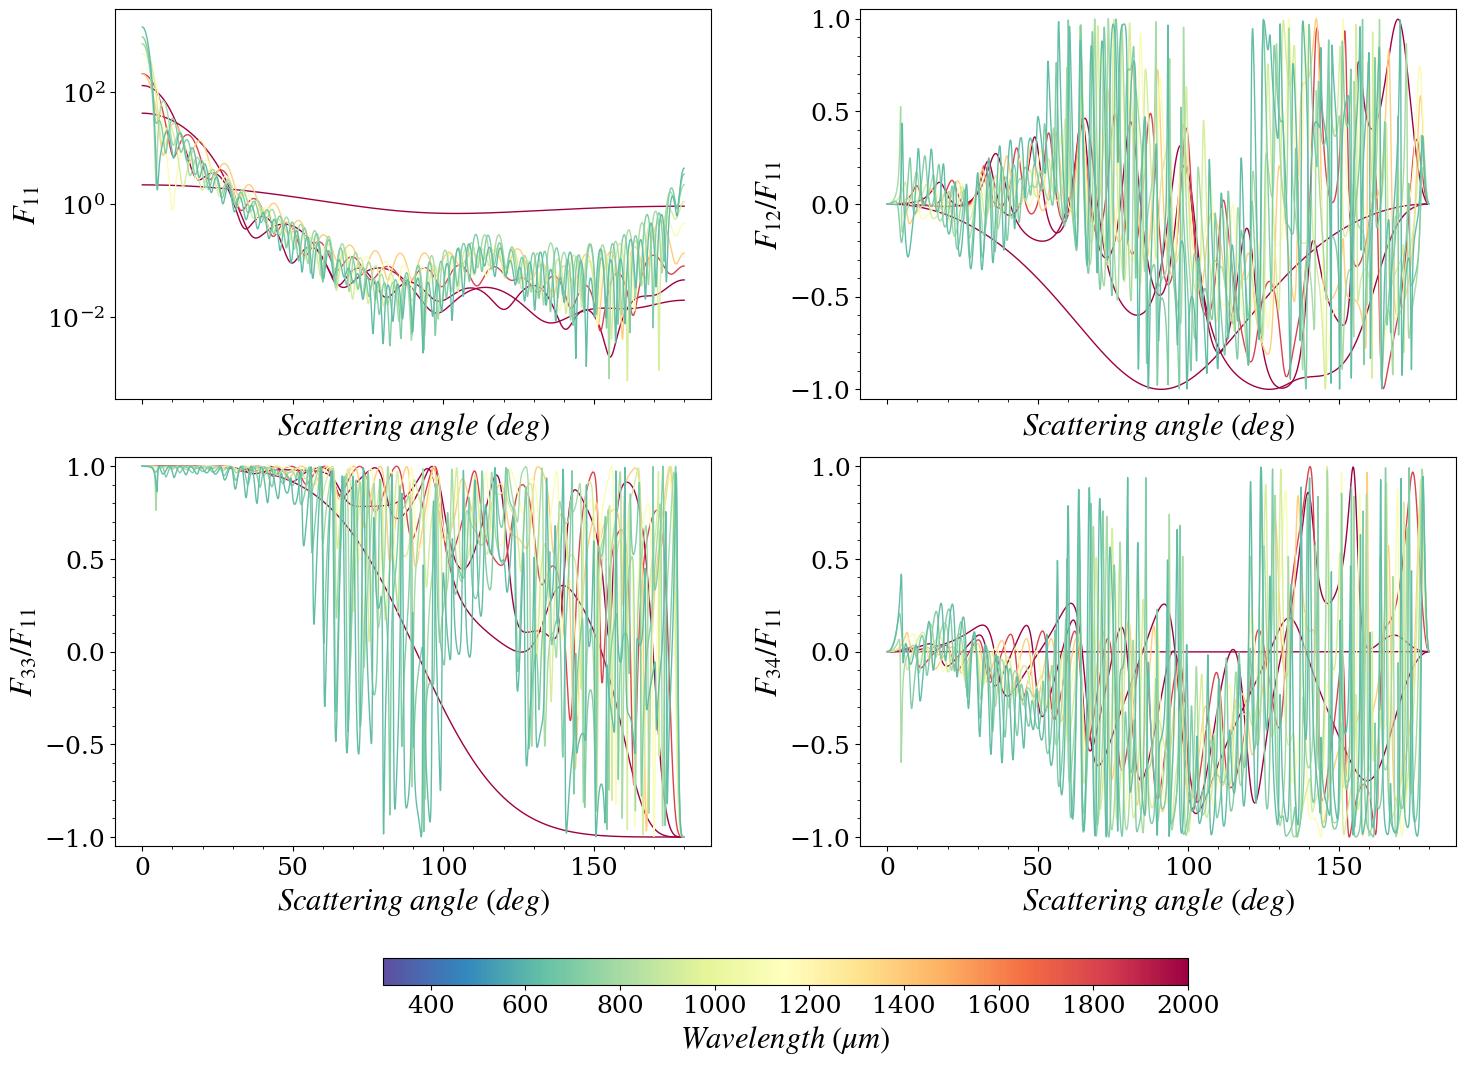

In [8]:
# set radius in nm
radius = 5e3

# Prepare color scale
cmap = plt.cm.Spectral_r #mpl.colors.LinearSegmentedColormap.from_list("",['navy', "blue", 'lightskyblue', 'gray', 'yellowgreen', 'forestgreen','gold','darkgoldenrod','darkred','black'])

norm = mpl.colors.Normalize(vmin=300, vmax=2000)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True)#, sharey='row')
fig.subplots_adjust(bottom=0.05, top=0.98, left=0.086, right=0.98,
                    hspace=0.15, wspace=0.25)
ang=np.degrees(theta)

for x, scat_mat_ in scat_mat.groupby('x'):

    wl = 2 * np.pi * radius / x
    S11 = scat_mat_.S11.squeeze()
    S12 = scat_mat_.S12.squeeze()
    S33 = scat_mat_.S33.squeeze()
    S34 = scat_mat_.S34.squeeze()
    
    
    norm_ = trapz(S11 * np.sin(theta), theta) / 2
    axs[0, 0].plot(ang, S11 / norm_, color=cmap(norm(wl)),lw=1)
    axs[0, 0].semilogy()
    axs[0, 1].plot(ang, S12 / S11, color=cmap(norm(wl)), lw=1)
    axs[1,0].plot(ang, S33 / S11, color=cmap(norm(wl)), lw=1)
    axs[1, 1].plot(ang, S34 / S11, color=cmap(norm(wl)), lw=1)

axs[0, 0].set_ylabel(r'$F_{11}$')
axs[0, 1].set_ylabel(r'$F_{12}/F_{11}$')
axs[1, 0].set_ylabel(r'$F_{33}/F_{11}$')
axs[1, 1].set_ylabel(r'$F_{34}/F_{11}$')

for i in range(2):
   
    for j in range(2):
        if (i==0) and (j==0):
            continue
        axs[i,j].set_ylim([-1.05, 1.05])

for ax in axs.ravel():
    ax.minorticks_on()
    ax.set_xlabel(r'$Scattering\ angle\ (deg)$')
cb = fig.colorbar(sm, ax=axs, shrink=0.6, aspect=30, pad=0.1, location='bottom')
cb.set_label('$Wavelength\ (\mu m)$', fontsize=22)

Check another refractive index

In [9]:
# set refractive index
m = 1.05 - 0.02j

# set size parameter
x=np.linspace(1,50,10)

# set scattering angles
theta = np.linspace(0, np.pi, 3600)

# proceed with computation
scat_mat = pmie.ScatMat_mp(m, x, theta)
scat_mat

<xarray.Dataset>
Dimensions:  (x: 10, theta: 3600)
Coordinates:
  * x        (x) float64 1.0 6.444 11.89 17.33 22.78 ... 33.67 39.11 44.56 50.0
  * theta    (theta) float64 0.0 0.0008729 0.001746 ... 3.14 3.141 3.142
    nr       float64 1.05
    ni       float64 -0.02
Data variables:
    S11      (x, theta) float64 0.001329 0.001329 ... 4.934e+03 4.936e+03
    S12      (x, theta) float64 0.0 -5.021e-10 -2.008e-09 ... 5.472 1.369 0.0
    S33      (x, theta) float64 0.001329 0.001329 ... -4.934e+03 -4.936e+03
    S34      (x, theta) float64 0.0 -1.771e-12 -7.082e-12 ... -0.04174 0.0
Attributes:
    description:  non-null scattering matrix terms from Mie computations usin...

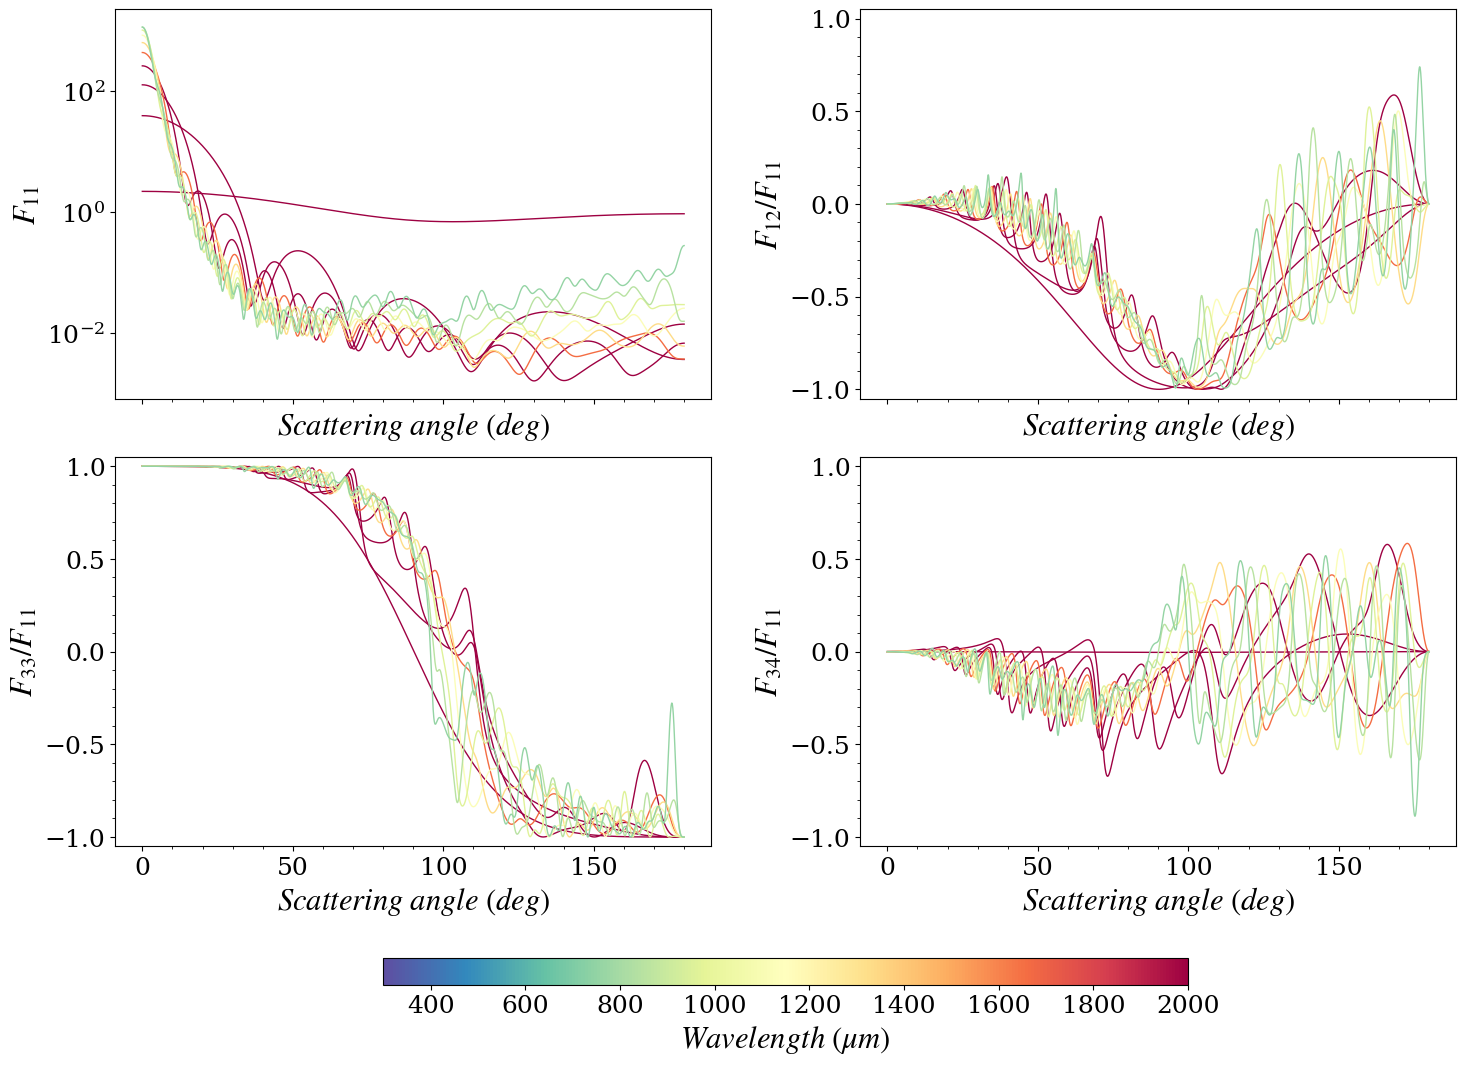

In [10]:
# set radius in nm
radius = 6e3

# Prepare color scale
cmap = plt.cm.Spectral_r #mpl.colors.LinearSegmentedColormap.from_list("",['navy', "blue", 'lightskyblue', 'gray', 'yellowgreen', 'forestgreen','gold','darkgoldenrod','darkred','black'])

norm = mpl.colors.Normalize(vmin=300, vmax=2000)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True)#, sharey='row')
fig.subplots_adjust(bottom=0.05, top=0.98, left=0.086, right=0.98,
                    hspace=0.15, wspace=0.25)
ang=np.degrees(theta)

for x, scat_mat_ in scat_mat.groupby('x'):

    wl = 2 * np.pi * radius / x
    S11 = scat_mat_.S11.squeeze()
    S12 = scat_mat_.S12.squeeze()
    S33 = scat_mat_.S33.squeeze()
    S34 = scat_mat_.S34.squeeze()
    
    
    norm_ = trapz(S11 * np.sin(theta), theta) / 2
    axs[0, 0].plot(ang, S11 / norm_, color=cmap(norm(wl)),lw=1)
    axs[0, 0].semilogy()
    axs[0, 1].plot(ang, S12 / S11, color=cmap(norm(wl)), lw=1)
    axs[1,0].plot(ang, S33 / S11, color=cmap(norm(wl)), lw=1)
    axs[1, 1].plot(ang, S34 / S11, color=cmap(norm(wl)), lw=1)

axs[0, 0].set_ylabel(r'$F_{11}$')
axs[0, 1].set_ylabel(r'$F_{12}/F_{11}$')
axs[1, 0].set_ylabel(r'$F_{33}/F_{11}$')
axs[1, 1].set_ylabel(r'$F_{34}/F_{11}$')

for i in range(2):
   
    for j in range(2):
        if (i==0) and (j==0):
            continue
        axs[i,j].set_ylim([-1.05, 1.05])

for ax in axs.ravel():
    ax.minorticks_on()
    ax.set_xlabel(r'$Scattering\ angle\ (deg)$')
cb = fig.colorbar(sm, ax=axs, shrink=0.6, aspect=30, pad=0.1, location='bottom')
cb.set_label('$Wavelength\ (\mu m)$', fontsize=22)

### Accounting for size distribution of particles in water
Warning: the wavelength should be converted of its value within the medium (i.e., water) like this:
--------
$\lambda_{medium}= \lambda_{vaccuum} / m_{medium}$
-------

In [65]:



# -------------------------------------
# Generate mueller matrices for a series
# of size parameters x = np.pi * diameter / wavelength (unitless)
# -------------------------------------
wl = 515
m_particle = 1.05 + 0.02j

mMedium = 1.3199+6878/wl**2-1.132e9/wl**4+1.11e14/wl**6
wl_medium=wl/mMedium

m = m_particle #/ mMedium 

theta = np.linspace(0, np.pi, 3600)
x = np.logspace(-1, np.log10(4000), 501)


### Run the full processing 
Warning: may take  several minutes on 40 CPUs
---------------------
You may save the outcomes into a netcdf files for future use

In [66]:
ofile = '/DATA/git/vrtc/mie_perso/data/mueller_mie_' + format(m,'1.3f') + '_t3600.nc'

if os.path.exists(ofile):
    mueller = xr.open_dataset(ofile)
else:
    mueller = pmie.ScatMat_mp(m, x, theta)
    mueller.to_netcdf(ofile)
mueller

<xarray.Dataset>
Dimensions:  (x: 501, theta: 3600)
Coordinates:
  * x        (x) float64 0.1 0.1021 0.1043 0.1066 ... 3.834e+03 3.916e+03 4e+03
  * theta    (theta) float64 0.0 0.0008729 0.001746 ... 3.14 3.141 3.142
    nr       float64 1.05
    ni       float64 0.02
Data variables:
    S11      (x, theta) float64 1.267e-09 1.267e-09 ... 2.76e+03 2.76e+03
    S12      (x, theta) float64 0.0 -4.827e-16 -1.931e-15 ... -0.009635 0.0
    S33      (x, theta) float64 1.267e-09 1.267e-09 ... -2.76e+03 -2.76e+03
    S34      (x, theta) float64 0.0 1.6e-20 6.401e-20 ... -0.0004627 0.0
Attributes:
    description:  non-null scattering matrix terms from Mie computations usin...

### convert mueller matrices for a series of diameters for a given couple of wavelength (in vacuum) and refractive index (in medium)  for a medium of refractive index nMedium
 -------------------------------------

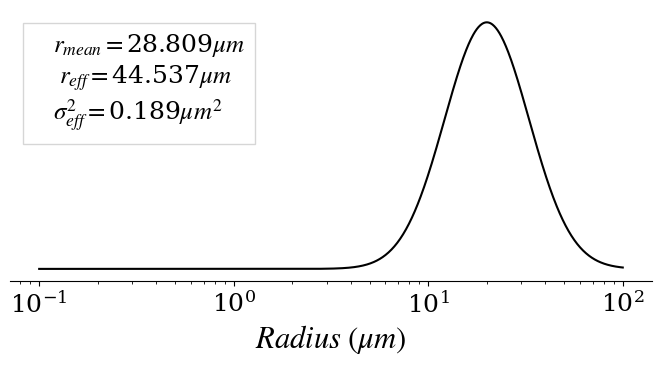

In [53]:
rn_med = 20 #[1., 10., 100., 1e3]
sigma = .5
#__________
# plot PSD
radius_super=np.logspace(-1,2,1000)

# compute size distribution
ndp = PSD().lognorm(radius_super, rn_med=rn_med, sigma=sigma)* np.pi * radius_super
# compute mean volume of the particles in micron**-3
ndp_norm = np.trapz(ndp, radius_super)
vol_mean = np.trapz(ndp * 4 / 3 * np.pi * radius_super ** 3, radius_super) / ndp_norm

plt.figure(figsize=(7, 4))
handles = [mpl.patches.Rectangle((0, 0), 1, 1, fc="white", ec="white",
                             lw=0, alpha=0)]
ax = plt.subplot(111)
ax.plot(radius_super, ndp,'k')

# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([])
plt.semilogx()
ax.set_xlabel('$Radius\ (\mu m)$')
ax.minorticks_on()
ax.legend(handles, [SizeParam(radius_super, ndp).to_annotation()], loc='best', fancybox=False,handlelength=0)
plt.tight_layout()

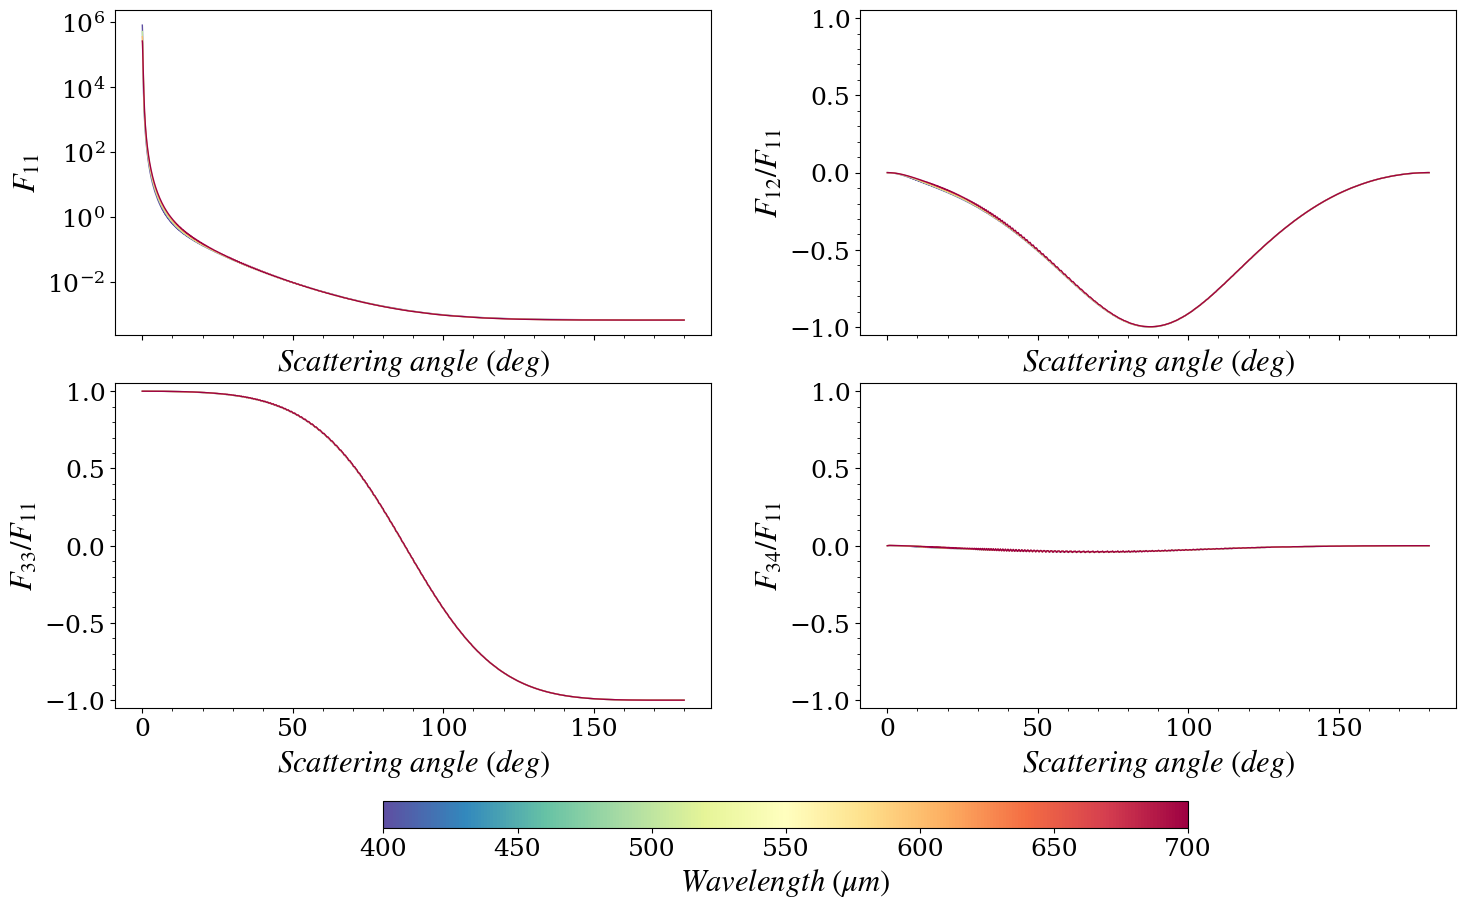

In [37]:


theta = mueller.theta
ang = theta * 180. / np.pi
Ntheta = len(mueller.theta)

m = complex(mueller.nr, mueller.ni)

# Prepare color scale
cmap = plt.cm.Spectral_r #mpl.colors.LinearSegmentedColormap.from_list("",['navy', "blue", 'lightskyblue', 'gray', 'yellowgreen', 'forestgreen','gold','darkgoldenrod','darkred','black'])

norm = mpl.colors.Normalize(vmin=400, vmax=700)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])



fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True)
fig.subplots_adjust(bottom=0.05, top=0.98, left=0.086, right=0.98,
                    hspace=0.15, wspace=0.25)

m_vacuum = m * mMedium
for wl in [400, 500, 600, 700]:
    wl_medium = wl / mMedium

    dpnm = mueller.x * wl_medium / np.pi
    dp = dpnm / 1000

 
    rv_med = PSD().rnmed2rvmed(rn_med, sigma)

    ndp = PSD().lognorm(dp / 2, rn_med=rn_med, sigma=sigma)
    # ndp = modif_power_law(dp / 2, slope=-slope, rmin=rmin, rmax=rmax)
    # convert to xarray
    ndp = dp.copy(data=ndp)

    # ndp = psd #[:-1]*np.diff(dp/2)
    S11, S12, S33, S34 = np.zeros(Ntheta), np.zeros(Ntheta), np.zeros(Ntheta), np.zeros(Ntheta)

    # aSDn = np.pi*((dp/2)**2)*ndp
    aSDn = ndp
    S11 = np.trapz(mueller.S11 * aSDn, dp, axis=0)
    S12 = np.trapz(mueller.S12 * aSDn, dp, axis=0)
    S33 = np.trapz(mueller.S33 * aSDn, dp, axis=0)
    S34 = np.trapz(mueller.S34 * aSDn, dp, axis=0)

    norm_ = trapz(S11 * np.sin(theta), theta) / 2
    axs[0, 0].plot(ang, S11 / norm_, color=cmap(norm(wl)), lw=1, label='$wl_0=$'+str(wl))
    axs[0, 0].semilogy()
    axs[0, 1].plot(ang, S12 / S11, color=cmap(norm(wl)), lw=1)
    axs[1, 0].plot(ang, S33 / S11, color=cmap(norm(wl)), lw=1)
    axs[1, 1].plot(ang, S34 / S11, color=cmap(norm(wl)), lw=1)




axs[0, 0].set_ylabel(r'$F_{11}$')
axs[0, 1].set_ylabel(r'$F_{12}/F_{11}$')
axs[1, 0].set_ylabel(r'$F_{33}/F_{11}$')
axs[1, 1].set_ylabel(r'$F_{34}/F_{11}$')

for i in range(2):
   
    for j in range(2):
        if (i==0) and (j==0):
            continue
        axs[i,j].set_ylim([-1.05, 1.05])

for ax in axs.ravel():
    ax.minorticks_on()
    ax.set_xlabel(r'$Scattering\ angle\ (deg)$')
cb = fig.colorbar(sm, ax=axs, shrink=0.6, aspect=30, pad=0.1, location='bottom')
cb.set_label('$Wavelength\ (\mu m)$', fontsize=22)

#plt.savefig('mie_perso/fig/beads_radius' + str(rn_med) + '_sig'+str(sig)+'_m' +format(m,'1.3f')+'.png', dpi=300)

### Generalize and produce input singlme scattering file for OSOAA software
First compute scattering, absorption, etc. dimensionless efficiency factor

In [43]:


mr=float(mueller.nr.values)
mi=float(mueller.nr.values)
p=[]
for x in mueller.x.values:
    p.append([x,mr, mi])
pool = multiprocessing.Pool(processes=38)
res = pool.map(pmie.Qeff_compute, p)




xQeff=pd.DataFrame(res,
                   columns=['x','mr','mi','Qext', 'Qsca', 'Qabs', 'g', 'Qpr', 'Qback', 'Qratio']
                   ).set_index(['x','mr','mi']).to_xarray()

xQeff#.to_netcdf(ofile)


<xarray.Dataset>
Dimensions:  (x: 501, mr: 1, mi: 1)
Coordinates:
  * x        (x) float64 0.1 0.1021 0.1043 0.1066 ... 3.834e+03 3.916e+03 4e+03
  * mr       (mr) float64 1.05
  * mi       (mi) float64 1.05
Data variables:
    Qext     (x, mr, mi) float64 0.2999 0.3064 0.313 ... 2.008 2.008 2.008
    Qsca     (x, mr, mi) float64 0.0001764 0.000192 0.000209 ... 1.293 1.293
    Qabs     (x, mr, mi) float64 0.2998 0.3062 0.3128 ... 0.7152 0.7152 0.7152
    g        (x, mr, mi) float64 0.00122 0.001273 0.001328 ... 0.819 0.819
    Qpr      (x, mr, mi) float64 0.2999 0.3064 0.313 ... 0.9492 0.9492 0.9491
    Qback    (x, mr, mi) float64 0.0002638 0.0002871 0.0003124 ... 0.2083 0.2083
    Qratio   (x, mr, mi) float64 1.495 1.495 1.495 ... 0.1611 0.1611 0.1611

Proceed with integration over size

In [44]:
scat_mat = []
CrossSection = []
wavelengths_nm = np.linspace(350,1001,50)
for wavelength in wavelengths_nm:
    wavelength_medium = wavelength / mMedium
    radius_nm = mueller.x * wavelength_medium / np.pi / 2
    radius_mic = 1e-3 * radius_nm
    radius = radius_mic

    scat_mat_ = []
    CrossSection_ = []
    
    # compute size distribution
    ndp = PSD().lognorm(radius, rn_med=rmed, sigma=sigma)

    # compute mean volume of the particles in micron**-3
    ndp_norm = np.trapz(ndp, radius)

    # integrate mueller matrix with size distribution (convert wavelength in micron)
    mueller_ = (wavelength_medium * 1e-3) ** 2 / np.pi * mueller.assign_coords(
        radius=("x", radius.data)) * ndp
    mueller_int = mueller_.integrate('radius').compute()/ndp_norm
    scat_mat.append(mueller_int.assign_coords({'r_med': rmed, 'wavelength': wavelength}))

    # compute cross section for size distribution in micron**2
    Csca_ = xQeff.Qsca.assign_coords(radius=("x", radius.data)) * (
            np.pi * radius.data ** 2 * ndp)
    Cext_ = xQeff.Qext.assign_coords(radius=("x", radius.data)) * (
            np.pi * radius.data ** 2 * ndp)
    Csca_int = Csca_.integrate('radius').compute().assign_coords({'r_med': rmed, 'wavelength': wavelength})/ndp_norm
    Cext_int = Cext_.integrate('radius').compute().assign_coords({'r_med': rmed, 'wavelength': wavelength})/ndp_norm
    CrossSection.append(xr.Dataset({'Csca': Csca_int, 'Cext': Cext_int}))

 

# concatenate xarray on the wavelength dimension
xCrossSection = xr.concat(CrossSection, dim='wavelength')
xscat_mat = xr.concat(scat_mat, dim='wavelength')
# TODO save into netcdf with good file naming

Check results

In [45]:
xCrossSection

<xarray.Dataset>
Dimensions:     (mr: 1, mi: 1, wavelength: 50)
Coordinates:
  * mr          (mr) float64 1.05
  * mi          (mi) float64 1.05
    nr          float64 1.05
    ni          float64 0.02
    r_med       float64 5.0
  * wavelength  (wavelength) float64 350.0 363.3 376.6 ... 974.4 987.7 1.001e+03
Data variables:
    Csca        (wavelength, mr, mi) float64 171.8 171.9 172.1 ... 175.5 175.5
    Cext        (wavelength, mr, mi) float64 267.3 267.5 267.7 ... 275.5 275.7

In [46]:
xscat_mat

<xarray.Dataset>
Dimensions:     (theta: 3600, wavelength: 50)
Coordinates:
  * theta       (theta) float64 0.0 0.0008729 0.001746 ... 3.14 3.141 3.142
    nr          float64 1.05
    ni          float64 0.02
    r_med       float64 5.0
  * wavelength  (wavelength) float64 350.0 363.3 376.6 ... 974.4 987.7 1.001e+03
Data variables:
    S11         (wavelength, theta) float64 8.675e+06 8.395e+06 ... 0.08928
    S12         (wavelength, theta) float64 0.0 -17.5 -60.16 ... 1.725e-07 0.0
    S33         (wavelength, theta) float64 8.675e+06 8.395e+06 ... -0.08928
    S34         (wavelength, theta) float64 0.0 168.4 593.5 ... -8.277e-07 0.0

Plot

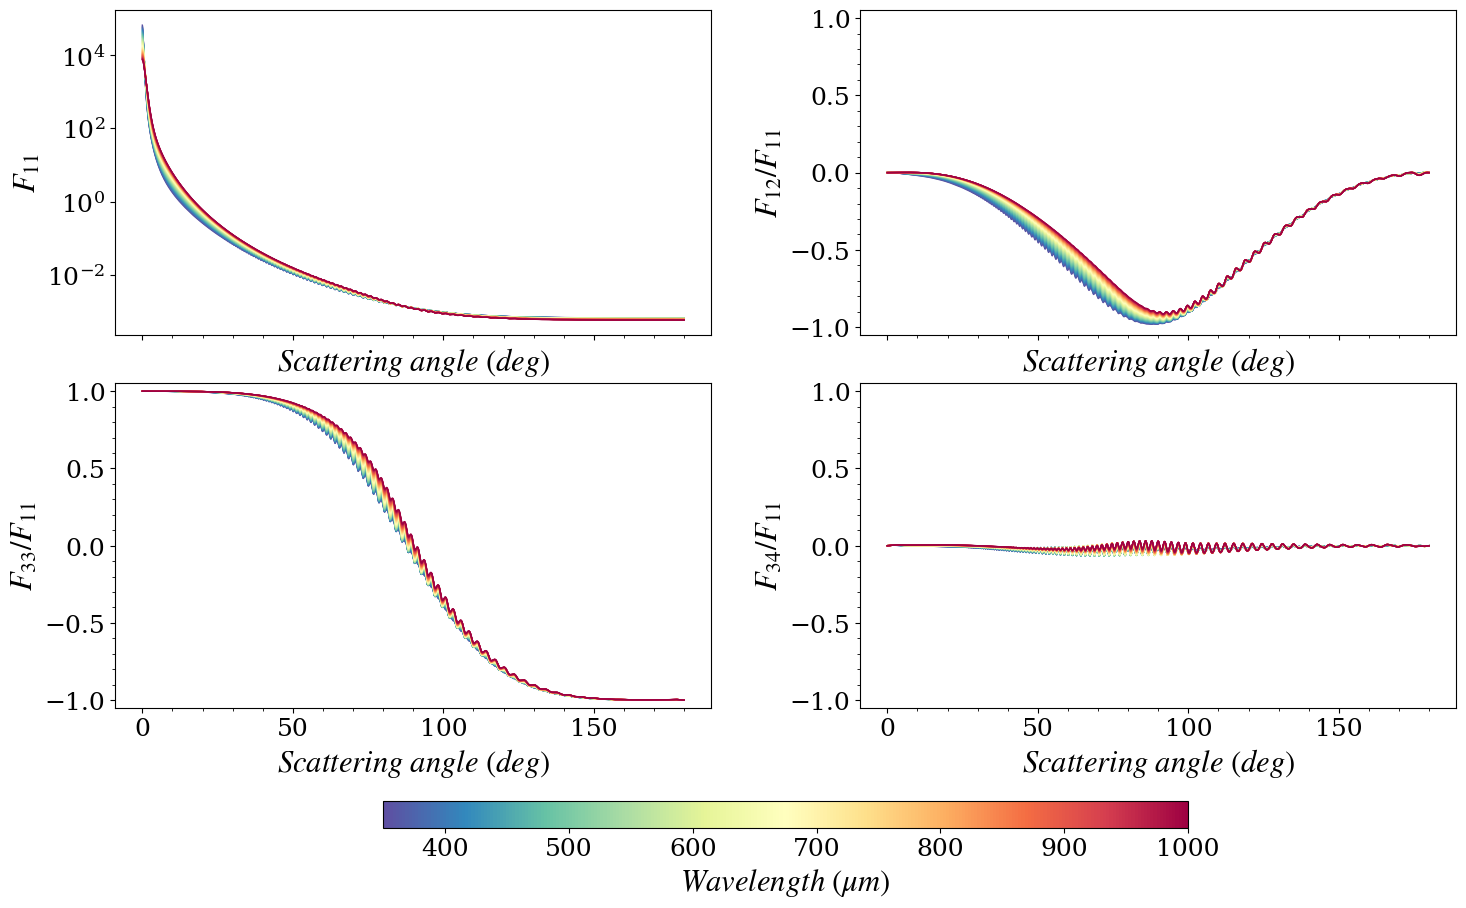

In [47]:
# Prepare color scale
cmap = plt.cm.Spectral_r #mpl.colors.LinearSegmentedColormap.from_list("",['navy', "blue", 'lightskyblue', 'gray', 'yellowgreen', 'forestgreen','gold','darkgoldenrod','darkred','black'])

norm = mpl.colors.Normalize(vmin=350, vmax=1000)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])



fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True)
fig.subplots_adjust(bottom=0.05, top=0.98, left=0.086, right=0.98,
                    hspace=0.15, wspace=0.25)

m_vacuum = m * mMedium
for wl, scat_mat_ in xscat_mat.groupby('wavelength'):
    
    S11 = scat_mat_.S11 
    S12 = scat_mat_.S12
    S33 = scat_mat_.S33 
    S34 = scat_mat_.S34 
    
    norm_ = trapz(S11 * np.sin(theta), theta) / 2
    axs[0, 0].plot(ang, S11 / norm_, color=cmap(norm(wl)), lw=1, label='$wl_0=$'+str(wl))
    axs[0, 0].semilogy()
    axs[0, 1].plot(ang, S12 / S11, color=cmap(norm(wl)), lw=1)
    axs[1, 0].plot(ang, S33 / S11, color=cmap(norm(wl)), lw=1)
    axs[1, 1].plot(ang, S34 / S11, color=cmap(norm(wl)), lw=1)




axs[0, 0].set_ylabel(r'$F_{11}$')
axs[0, 1].set_ylabel(r'$F_{12}/F_{11}$')
axs[1, 0].set_ylabel(r'$F_{33}/F_{11}$')
axs[1, 1].set_ylabel(r'$F_{34}/F_{11}$')

for i in range(2):
   
    for j in range(2):
        if (i==0) and (j==0):
            continue
        axs[i,j].set_ylim([-1.05, 1.05])

for ax in axs.ravel():
    ax.minorticks_on()
    ax.set_xlabel(r'$Scattering\ angle\ (deg)$')
cb = fig.colorbar(sm, ax=axs, shrink=0.6, aspect=30, pad=0.1, location='bottom')
cb.set_label('$Wavelength\ (\mu m)$', fontsize=22)

#plt.savefig('mie_perso/fig/beads_radius' + str(rn_med) + '_sig'+str(sig)+'_m' +format(m,'1.3f')+'.png', dpi=300)

In [63]:
path_of_your_file='osoaa_input_test.csv'

# ----------------------------------------
# Generate OSOAA scat mat file
wavelength=443.0
xscat_mat_ = xscat_mat.sel(wavelength=wavelength).squeeze()
xCrossSection_ = xCrossSection.sel(wavelength=wavelength).squeeze()

S11 = scat_mat_.S11 
S12 = scat_mat_.S12/S11
S33 = scat_mat_.S33/S11 
S34 = scat_mat_.S34/S11 
    
norm_ = trapz(S11 * np.sin(theta), theta) / 2
S11= S11/norm_
# set S22 to one
S22=S11*0+1
mat = xr.Dataset({'s11':S11,'s12':S12,'s22':S22,'s33':S33})
mat = mat.assign_coords(theta=np.degrees(mat.theta))
df_mat = mat.reset_coords(drop=True).to_pandas()
Nang = len(xscat_mat_.theta)

Cext_ = "{:12.6e}".format(xCrossSection_.Cext.values)
Csca_ = "{:12.6e}".format(xCrossSection_.Csca.values)
V_mean_ = "{:12.6e}".format(vol_mean)
# check normalization:
theta_rad = np.deg2rad(df_mat.index)


header = 'Cext : '+Cext_+'\nCsca : '+Csca_+'\nvol_mean : '+V_mean_+\
         '\nNb angles : '+str(Nang)+'\n'

with open(path_of_your_file, 'w') as fp:
    fp.write(header)
df_mat.to_csv(path_of_your_file,sep=' ', header=True, mode='a')